# Lazypredict

In [33]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

In [34]:
# Data Preparation
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    '% NBKP', #1
    'Mean_Load KWH Refiner',
    'Mean_Creping',
    'Mean_Jet Wire Ratio',
    'pseudo_mass',
    'coating_release_ratio'
]
X = df[features]

# Y Variables
df['y_variable'] = (df['MDT'] / df['GSM'])
target = df['y_variable']
y = target

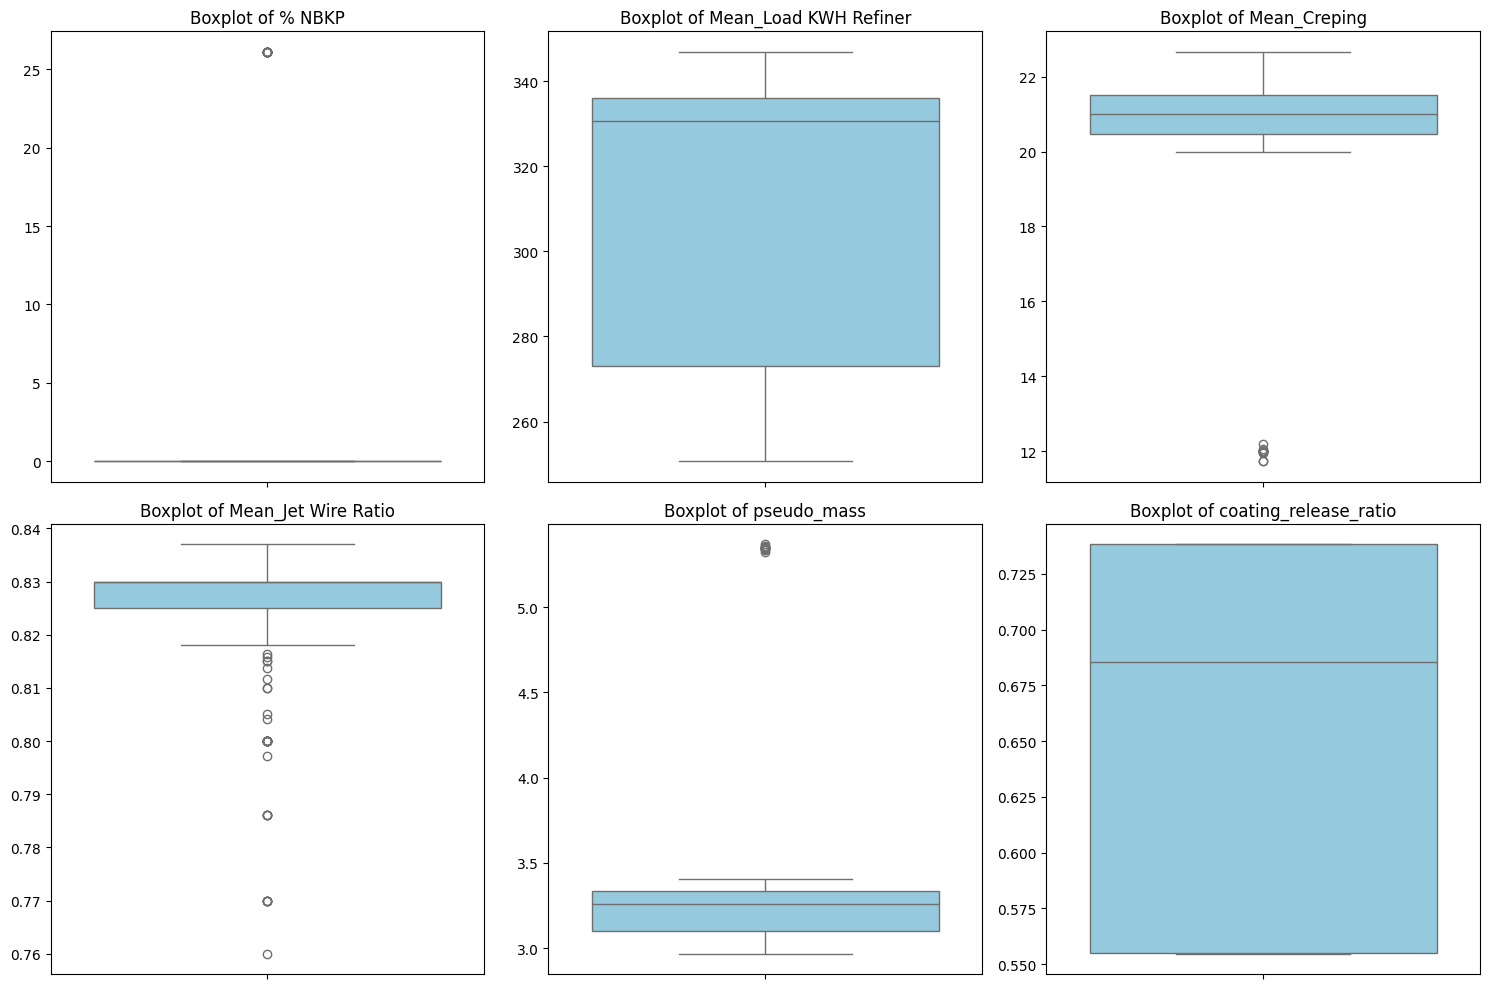

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan list fitur sesuai dengan yang ada di gambar kamu
features = [
    '% NBKP', 
    'Mean_Load KWH Refiner', 
    'Mean_Creping', 
    'Mean_Jet Wire Ratio', 
    'pseudo_mass', 
    'coating_release_ratio'
]

# Menentukan layout grid (misal: 2 baris x 3 kolom)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Flatten axes agar mudah diiterasi dengan satu loop
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel('') # Menghilangkan label y agar tidak terlalu penuh

# Mengatur tata letak agar tidak tumpang tindih
plt.tight_layout()
plt.show()

In [36]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

In [38]:
# Hitung MAPE untuk tiap model
mape_scores = {}

for model_name, y_pred in predictions.items():
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mape_scores[model_name] = mape

# Tambahkan ke tabel hasil
models["MAPE"] = pd.Series(mape_scores)

# Urutkan (semakin kecil semakin baik)
models = models.sort_values(by="MAPE")

In [39]:
print(models)

                               Adjusted R-Squared   R-Squared        RMSE  \
Model                                                                       
ExtraTreesRegressor                      0.789294    0.824412    3.079778   
RandomForestRegressor                    0.707079    0.755899    3.631253   
GradientBoostingRegressor                0.701216    0.751013    3.667414   
ExtraTreeRegressor                       0.684976    0.737480    3.765761   
HistGradientBoostingRegressor            0.672582    0.727152    3.839126   
Lasso                                    0.639652    0.699710    4.027561   
LassoLars                                0.639575    0.699645    4.027995   
BaggingRegressor                         0.633122    0.694268    4.063893   
SGDRegressor                             0.603146    0.669288    4.226653   
ElasticNetCV                             0.601548    0.667957    4.235154   
ElasticNet                               0.596688    0.663907    4.260902   

# Random Forest Regressor

In [40]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Data -> sudah sebelumnya
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Inisialisasi Model Random Forest
model = ExtraTreesRegressor(
    n_estimators=200,     # jumlah pohon
    max_depth=None,       # kedalaman pohon (None = bebas)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1             # gunakan semua core CPU
)

# Training Model
model.fit(X_train, y_train)
# Prediksi
y_pred = model.predict(X_test)

# Evaluasi Model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# MAPE Manual (aman)
epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))

print("R2       :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)
print("MAPE     :", mape)

R2       : 0.8249062668314648
RMSE     : 3.0754394600222237
MAE      : 2.3905733024604126
MAPE     : 0.04392057772020904


### Features Importance

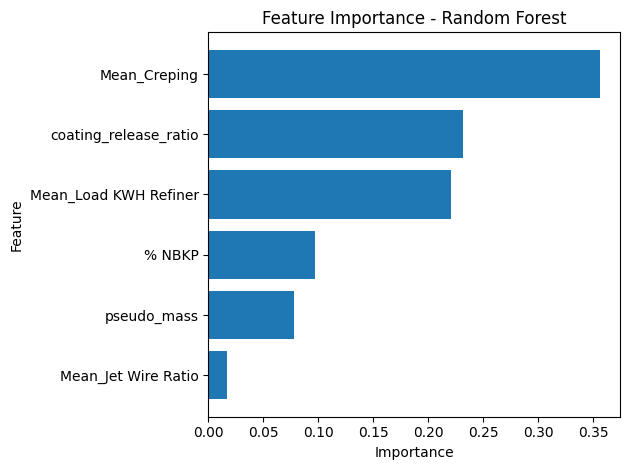

In [41]:
# Feature Importance
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": features, 
    "Importance": model.feature_importances_
})

# Urutkan dari terbesar
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)


# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

### SHAP Analysis

In [42]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [43]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

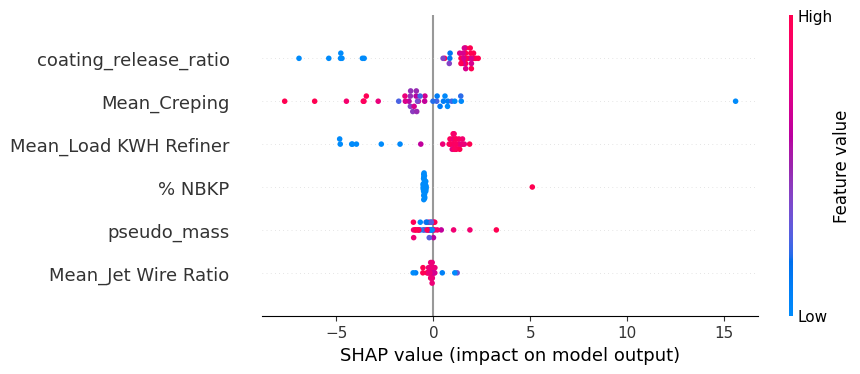

In [44]:
shap.plots.beeswarm(shap_values, max_display=10)

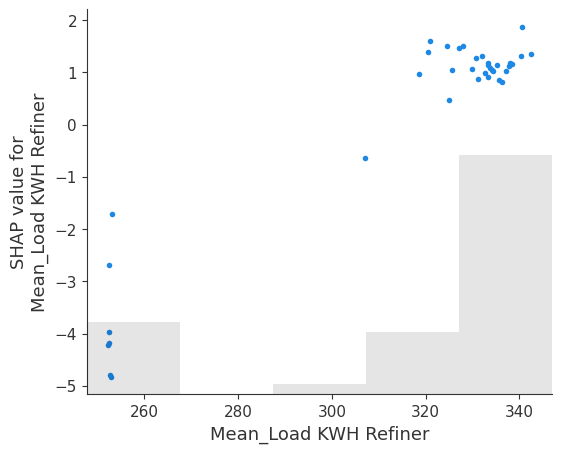

In [45]:
# Scatter plot dasar - melihat tren arah secara mendetail
shap.plots.scatter(shap_values[:, "Mean_Load KWH Refiner"])

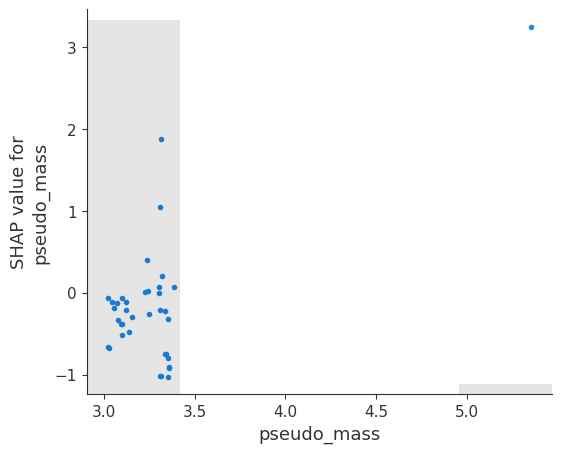

In [46]:
shap.plots.scatter(shap_values[:, "pseudo_mass"])

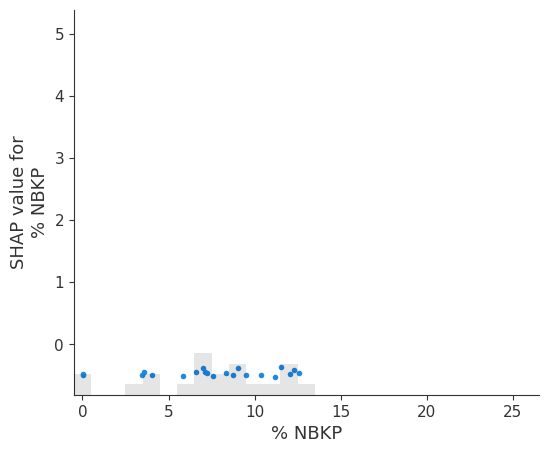

In [47]:
shap.plots.scatter(shap_values[:, "% NBKP"])

In [48]:
shap_values = explainer.shap_values(np.array(X_test))
shap.initjs()
i = 0  # index data

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)